In [1]:
from xrss.dataloader import XRayDataset, show_images_and_bboxes
from xrss.utils import (
    xyxy_to_yolo,
    yolo_to_xyxy,
    compute_iou,
    compute_predictions_folder,
    yolo_to_submission_csv,
)
from xrss.models import PixelTemplateMatching

from tqdm import tqdm
import itertools
import pandas as pd
import cv2
import numpy as np

# Model Initialization and qualitative testing

In [2]:
yaml_file = "../xray_data/data.yaml"

train_dataset = XRayDataset(yaml_file, split="train", resize=False)
val_dataset = XRayDataset(yaml_file, split="val", resize=False)

In [ ]:
model = PixelTemplateMatching(
    max_templates_per_class=700,
    threshold=0.8,
    nms_threshold=0.2,
    custom_threshold={5: 0.98},
)
model.train(train_dataset)

Extracting up to 700 templates per class, from 4200 images.


 82%|████████▏ | 3453/4200 [00:02<00:00, 1153.22it/s]

Training complete.
Class 0: 700 templates
Class 1: 700 templates
Class 2: 700 templates
Class 3: 700 templates
Class 4: 700 templates
Class 5: 700 templates


Displaying sample images with ground truth bounding boxes:


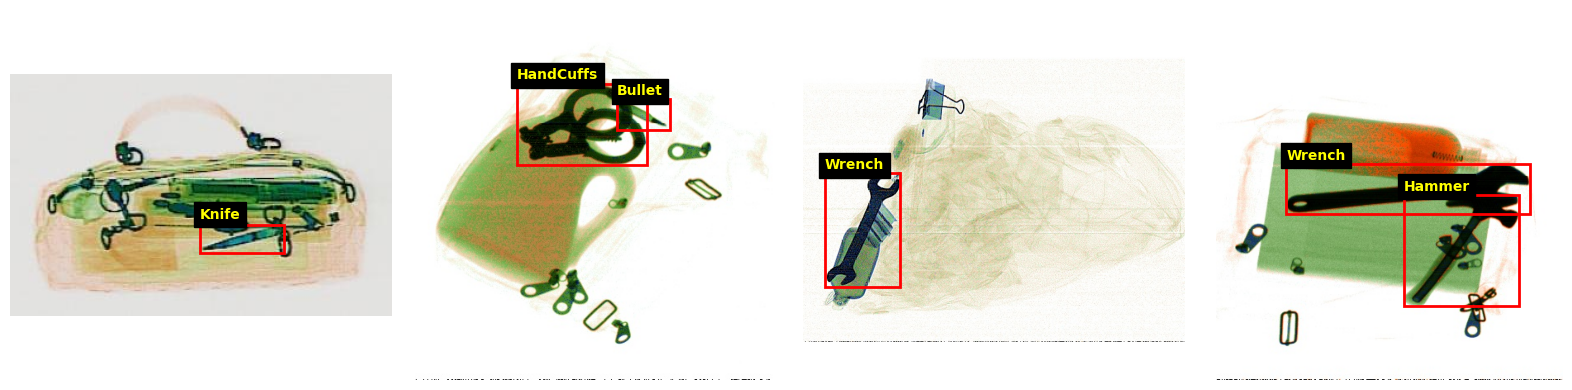

Displaying sample images with predicted bounding boxes:


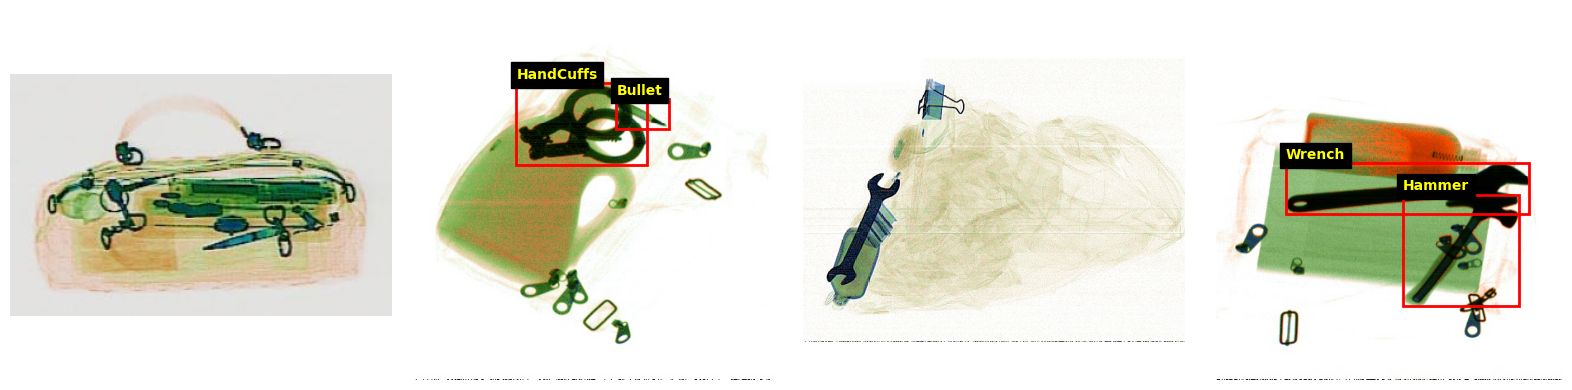

In [12]:
indexes = list(range(4))

images = [val_dataset[i][0] for i in indexes]
labels = [val_dataset[i][1] for i in indexes]

print("Displaying sample images with ground truth bounding boxes:")
show_images_and_bboxes(val_dataset, images, labels, cols=4)

preds = []
for img in images:
    preds.append(model.detect(img))

print("Displaying sample images with predicted bounding boxes:")
show_images_and_bboxes(val_dataset, images, preds, cols=4)

# Tuning hyperparameters (thresholds and NMS) on validation set

In [ ]:
# Limit number of templates for faster inference during hyperparameter search
max_template = 300
thresholds = [0.8, 0.85, 0.9, 0.95]
nms_thresholds = [0.3, 0.4, 0.5, 0.6]

min_conf_scan = min(thresholds)

# Train once
model = PixelTemplateMatching(max_templates_per_class=max_template)
model.train(train_dataset)

# We store predictions BEFORE NMS so we can re-apply NMS with different params later
cached_predictions = []
ground_truths = []

for i in tqdm(range(len(val_dataset))):
    img_pil, gt_labels = val_dataset[i]
    ground_truths.append(gt_labels)

    img_gray = cv2.cvtColor(np.array(img_pil), cv2.COLOR_RGB2GRAY)
    h_img, w_img = img_gray.shape

    img_raw_boxes = []
    img_raw_scores = []
    img_raw_classes = []

    for cls_id, templates in model.templates.items():
        for template in templates:
            h_temp, w_temp = template.shape
            if h_temp >= h_img or w_temp >= w_img:
                continue

            res = cv2.matchTemplate(img_gray, template, cv2.TM_CCOEFF_NORMED)

            # Use the lowest threshold in our grid to catch EVERYTHING we might need
            y_loc, x_loc = np.where(res >= min_conf_scan)

            if len(y_loc) > 0:
                scores = res[y_loc, x_loc]
                n = len(scores)

                boxes = np.column_stack(
                    (x_loc, y_loc, np.full(n, w_temp), np.full(n, h_temp))
                )

                img_raw_boxes.append(boxes)
                img_raw_scores.append(scores)
                img_raw_classes.append(np.full(n, cls_id))

    # Store candidates for this image
    if img_raw_boxes:
        cached_predictions.append(
            {
                "boxes": np.concatenate(img_raw_boxes),
                "scores": np.concatenate(img_raw_scores),
                "classes": np.concatenate(img_raw_classes),
                "dims": (w_img, h_img),
            }
        )
    else:
        cached_predictions.append(None)  # No detections found

In [ ]:
# Fast grid search over cached predictions
results = []
combinations = list(itertools.product(thresholds, nms_thresholds))

for thresh, iou_thresh in tqdm(combinations):
    frame_scores = []

    for img_idx, raw_data in enumerate(cached_predictions):
        gt = ground_truths[img_idx]
        num_gt = len(gt)

        final_preds_yolo = []

        if raw_data is not None:
            mask = raw_data["scores"] >= thresh

            if np.any(mask):
                f_boxes = raw_data["boxes"][mask]
                f_scores = raw_data["scores"][mask]
                f_classes = raw_data["classes"][mask]
                w_img, h_img = raw_data["dims"]

                indices = cv2.dnn.NMSBoxes(
                    bboxes=f_boxes.tolist(),
                    scores=f_scores.tolist(),
                    score_threshold=thresh,
                    nms_threshold=iou_thresh,
                )

                if len(indices) > 0:
                    for idx in indices.flatten():
                        x, y, w, h = f_boxes[idx]
                        cls_id = f_classes[idx]
                        yolo_pred = xyxy_to_yolo(
                            int(cls_id), x, y, x + w, y + h, w_img, h_img
                        )
                        final_preds_yolo.append(yolo_pred)

        num_pred = len(final_preds_yolo)

        if num_gt == 0 and num_pred == 0:
            frame_scores.append(1.0)
            continue
        if num_gt == 0 or num_pred == 0:
            frame_scores.append(0.0)
            continue

        used_preds = set()
        total_iou = 0.0

        for g in gt:
            gt_cls = int(g[0])
            gt_box = yolo_to_xyxy(g, w_img, h_img)
            best_iou = 0.0
            best_match = -1

            for p_idx, p in enumerate(final_preds_yolo):
                if p_idx in used_preds:
                    continue
                if int(p[0]) != gt_cls:
                    continue

                p_box = yolo_to_xyxy(p, w_img, h_img)
                iou_val = compute_iou(gt_box, p_box)

                if iou_val > best_iou:
                    best_iou = iou_val
                    best_match = p_idx

            if best_match != -1:
                total_iou += best_iou
                used_preds.add(best_match)

        frame_scores.append(total_iou / max(num_gt, num_pred))

    # Average score for this config
    avg_score = np.mean(frame_scores)
    results.append({"threshold": thresh, "iou": iou_thresh, "score": avg_score})

# Display top results
df = pd.DataFrame(results)
print("\nTop 5 Configurations:")
display(df.sort_values(by="score", ascending=False).head(5))

# Compute predictions on test set and create submission file

In [ ]:
test_dataset = XRayDataset(yaml_file, split="test")
output_folder = "../predictions/PTM_test/"

model = PixelTemplateMatching(
    max_templates_per_class=700,
    threshold=0.8,
    nms_threshold=0.2,
    custom_threshold={5: 0.98},
)
model.train(train_dataset)

compute_predictions_folder(
    model, test_dataset, output_folder=output_folder, replace=False
)

In [ ]:
yolo_to_submission_csv(output_folder, "../results/PTM_submission.csv")